# Load the dataset

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('/content/sample_data/entrepreneurship_practice_dataset.csv')
df.head(5)

,startup_id,founded_year,country,industry,funding_stage,total_funding_musd,num_employees,annual_revenue_musd,valuation_busd,customer_base_millions,social_media_followers,marketing_spend_musd,has_female_founder,primary_tech_stack,ceo_age,num_founders,has_patent,monthly_website_visits,investor_count,acquired_or_ipo
0,ST1000,2011.0,Singapore,FinTech,Series B,70.83,NaN,37.73,NaN,0.697,57461.0,2.05,No,Python,39.0,2.0,Yes,NaN,20.0,Yes
1,ST1001,2019.0,India,SaaS,Series B,75.18,NaN,77.75,2.426,0.836,134831.0,4.84,No,JavaScript,42.0,1.0,NaN,NaN,25.0,Yes
2,ST1002,2015.0,Singapore,CleanTech,Series B,48.47,428.0,45.65,NaN,1.457,42862.0,NaN,No,PHP,32.0,1.0,No,61828.0,17.0,No
3,ST1003,2012.0,UAE,HealthTech,Series B,8.18,55.0,11.40,NaN,0.188,6740.0,2.91,No,JavaScript,35.0,3.0,No,NaN,NaN,No
4,ST1004,2011.0,Nigeria,AgriTech,Series B,49.08,444.0,66.59,NaN,0.978,NaN,NaN,Yes,Ruby,34.0,2.0,No,NaN,25.0,No


## df.columns()

In [4]:
df.columns

Index(['startup_id', 'founded_year', 'country', 'industry', 'funding_stage',
       'total_funding_musd', 'num_employees', 'annual_revenue_musd',
       'valuation_busd', 'customer_base_millions', 'social_media_followers',
       'marketing_spend_musd', 'has_female_founder', 'primary_tech_stack',
       'ceo_age', 'num_founders', 'has_patent', 'monthly_website_visits',
       'investor_count', 'acquired_or_ipo'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   startup_id              500 non-null    object 
 1   founded_year            460 non-null    float64
 2   country                 450 non-null    object 
 3   industry                500 non-null    object 
 4   funding_stage           500 non-null    object 
 5   total_funding_musd      410 non-null    float64
 6   num_employees           390 non-null    float64
 7   annual_revenue_musd     350 non-null    float64
 8   valuation_busd          175 non-null    float64
 9   customer_base_millions  375 non-null    float64
 10  social_media_followers  425 non-null    float64
 11  marketing_spend_musd    325 non-null    float64
 12  has_female_founder      410 non-null    object 
 13  primary_tech_stack      425 non-null    object 
 14  ceo_age                 400 non-null    fl

## check unique value

In [6]:
df.nunique()

,0
startup_id,500
founded_year,19
country,10
industry,10
funding_stage,6
total_funding_musd,319
num_employees,222
annual_revenue_musd,308
valuation_busd,145
customer_base_millions,312


## Check missing count

In [7]:
df.shape

(500, 20)

In [8]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing[missing["Missing Count"] > 0]
missing = missing.sort_values("Missing %", ascending=False)

missing

,Missing Count,Missing %
valuation_busd,325,65.0
marketing_spend_musd,175,35.0
monthly_website_visits,160,32.0
annual_revenue_musd,150,30.0
has_patent,140,28.0
customer_base_millions,125,25.0
investor_count,120,24.0
num_employees,110,22.0
ceo_age,100,20.0
has_female_founder,90,18.0


## info()

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   startup_id              500 non-null    object 
 1   founded_year            460 non-null    float64
 2   country                 450 non-null    object 
 3   industry                500 non-null    object 
 4   funding_stage           500 non-null    object 
 5   total_funding_musd      410 non-null    float64
 6   num_employees           390 non-null    float64
 7   annual_revenue_musd     350 non-null    float64
 8   valuation_busd          175 non-null    float64
 9   customer_base_millions  375 non-null    float64
 10  social_media_followers  425 non-null    float64
 11  marketing_spend_musd    325 non-null    float64
 12  has_female_founder      410 non-null    object 
 13  primary_tech_stack      425 non-null    object 
 14  ceo_age                 400 non-null    fl

## describe()

In [10]:
df.describe()

,founded_year,total_funding_musd,num_employees,annual_revenue_musd,valuation_busd,customer_base_millions,social_media_followers,marketing_spend_musd,ceo_age,num_founders,monthly_website_visits,investor_count
count,460.000000,410.000000,390.000000,350.000000,175.000000,375.000000,425.000000,325.000000,400.000000,440.000000,340.000000,380.000000
mean,2013.650000,29.717732,261.576923,28.269971,0.930291,0.494731,49613.574118,4.092308,37.557500,1.913636,32052.350000,10.423684
std,5.678889,56.750097,465.577153,58.772278,1.837679,0.479897,51035.881208,9.130836,9.369694,0.891261,33444.059881,18.232939
min,2005.000000,0.070000,0.000000,0.000000,0.001000,0.000000,369.000000,0.000000,12.000000,1.000000,430.000000,0.000000
25%,2009.000000,0.587500,24.250000,1.645000,0.027500,0.147000,14974.000000,0.220000,32.000000,1.000000,10699.500000,1.000000
50%,2013.000000,4.200000,63.000000,4.220000,0.142000,0.323000,31652.000000,0.690000,38.000000,2.000000,19871.500000,3.000000
75%,2019.000000,21.512500,197.750000,22.540000,0.748000,0.691500,67075.000000,3.560000,44.000000,2.000000,41335.250000,9.000000
max,2023.000000,309.900000,2504.000000,401.630000,12.268000,2.586000,335978.000000,63.190000,66.000000,4.000000,202084.000000,97.000000


# Split the datasets

In [23]:
from sklearn.model_selection import train_test_split

In [52]:
X = df.drop(columns=["acquired_or_ipo"])
y = df["acquired_or_ipo"]
y = y.map({"Yes": 1, "No": 0})
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fixed the target column

In [39]:
y

,acquired_or_ipo
0,1
1,1
2,0
3,0
4,0
...,...
495,1
496,1
497,1
498,0


## Divide numeric & Catg cols

In [40]:
num_cols= X.select_dtypes(include=['number']).columns

catg_cols = X.select_dtypes(include=['object','category']).columns

In [41]:
num_cols

Index(['founded_year', 'total_funding_musd', 'num_employees',
       'annual_revenue_musd', 'valuation_busd', 'customer_base_millions',
       'social_media_followers', 'marketing_spend_musd', 'ceo_age',
       'num_founders', 'monthly_website_visits', 'investor_count'],
      dtype='object')

In [42]:
catg_cols

Index(['startup_id', 'country', 'industry', 'funding_stage',
       'has_female_founder', 'primary_tech_stack', 'has_patent'],
      dtype='object')

## Check the distribution before imputation

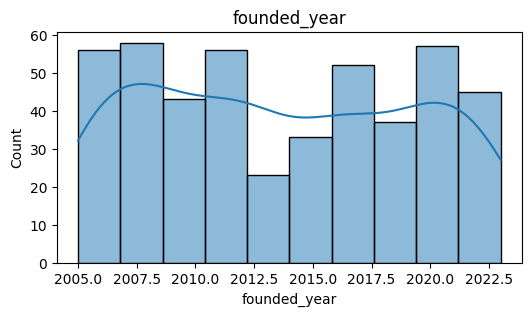

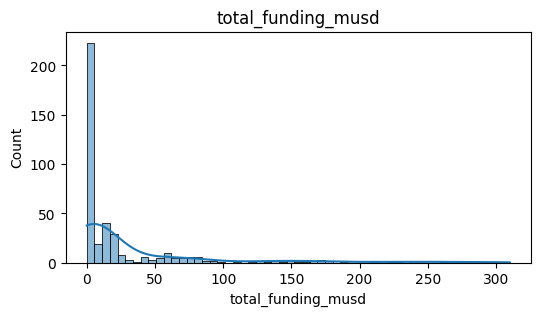

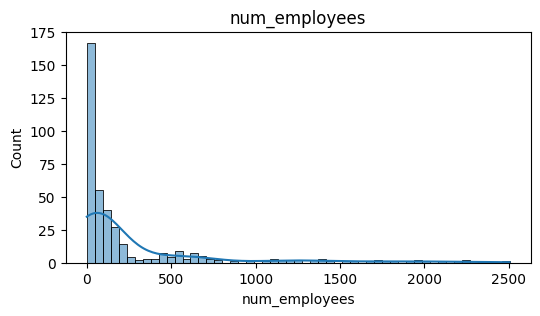

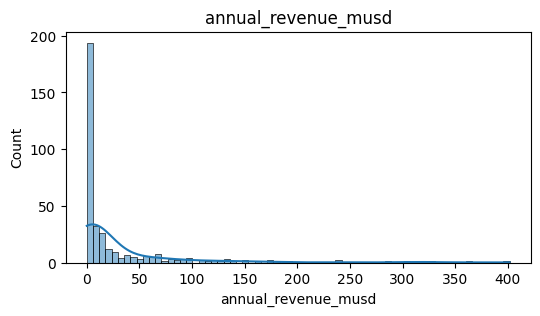

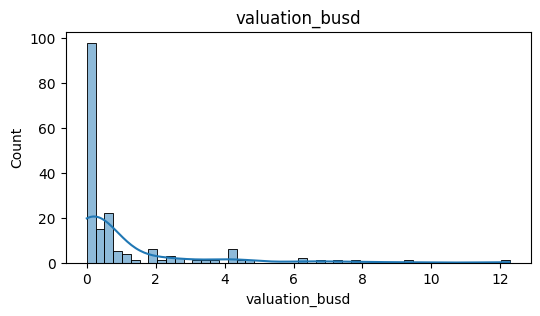

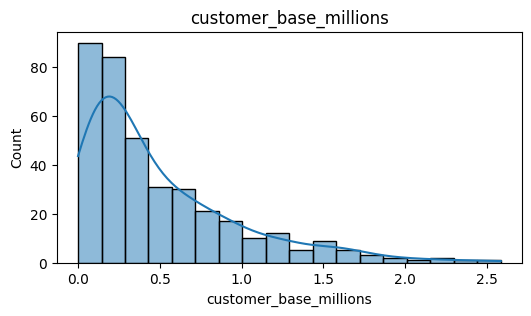

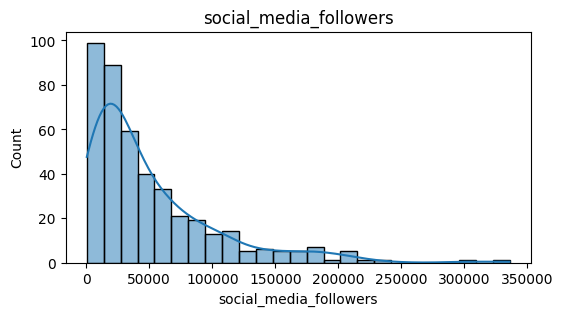

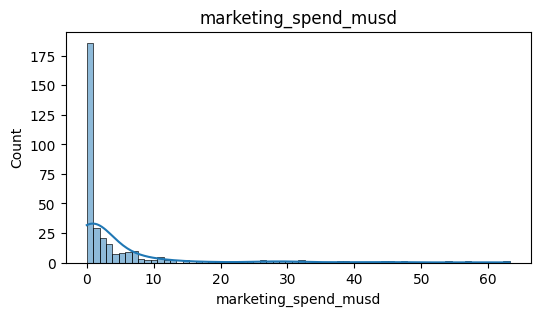

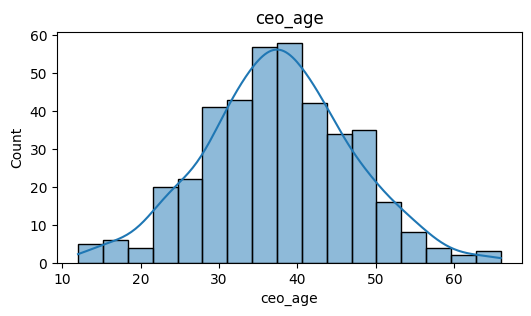

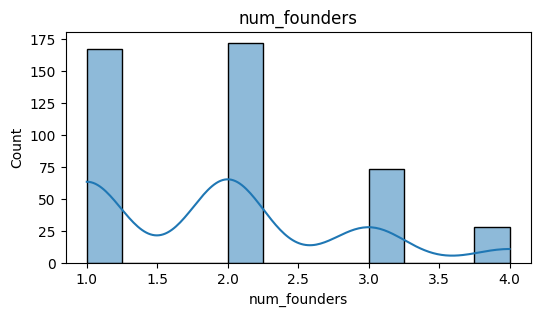

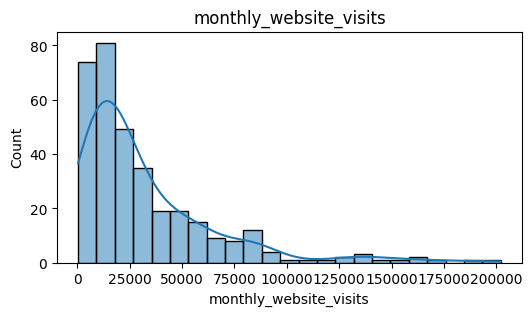

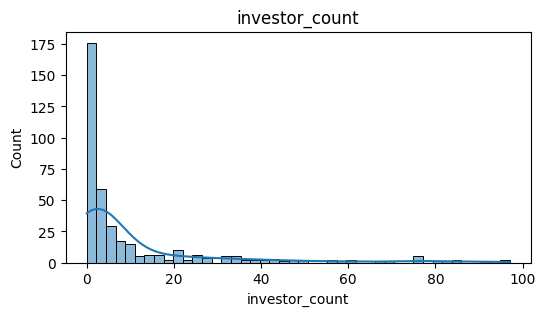

In [28]:


for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

## calculate the skewness

In [29]:
df[num_cols].skew().sort_values()

,0
ceo_age,0.034456
founded_year,0.079925
num_founders,0.713132
customer_base_millions,1.549183
social_media_followers,1.909694
monthly_website_visits,2.175645
num_employees,2.687621
investor_count,2.695859
total_funding_musd,2.755442
valuation_busd,3.215773


 > Between -0.5 and 0.5: Approximately symmetric

 > .Between -1.0 and -0.5 (or 0.5 and 1.0): Moderately skewed.


 > Less than -1.0 (or greater than 1.0): Highly skewed

> So, we use median

# Handling Missing value

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

## handling numerical cols

In [31]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

## Catgc pipeline

In [32]:
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="Unknown"
        )
    ),
    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore")
    )
])

## combine

 > Combine both pipelines

In [33]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, catg_cols)
])

# **Define All Four Model**

 > After preprocessoring we will apply the each model

#Random Forest

In [34]:
from sklearn.ensemble import RandomForestClassifier

RF_Pipeline = Pipeline([
    ("Preprocessor",preprocessor),
    ("Classifier", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        random_state= 42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

## cross validation

In [44]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv_scores = cross_val_score(
    RF_Pipeline, X_train, y_train,
    cv=cv,
    scoring="average_precision",  # this is AUC-PR
    n_jobs=-1
)

print("CV AUC-PR scores per fold:", rf_cv_scores)
print(f"CV AUC-PR mean: {rf_cv_scores.mean():.4f}")
print(f"CV AUC-PR std:  {rf_cv_scores.std():.4f}")

CV AUC-PR scores per fold: [0.60831916 0.7217325  0.66510707 0.53837596 0.56732743]
CV AUC-PR mean: 0.6202
CV AUC-PR std:  0.0663


## Train the Final RandomForest

In [45]:
RF_Pipeline.fit(X_train, y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['founded_year', 'total_funding_musd', 'num_employees',
       'annual_revenue_musd', 'valuation_busd', 'customer_base_millions',
       'social_media_followers', 'marketing_spend_musd', 'ceo_age',
       'num_founders', 'monthly_website_vis...
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['startup_id', 'country', 'industry', 'funding_stage',
       'has_female_founder', 'primary_tech_stack', 'has_patent'],
      dtype='object'))])),
                ('Classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=2, n_estimators=300,
                                        n_jobs=1, random_state=42))])

## Predict on Validation Set

In [47]:
RF_pred = RF_Pipeline.predict(X_test)
RF_proba = RF_Pipeline.predict_proba(X_test)[:, 1]

## Evaluate — Precision, Recall, F1, AUC-PR

In [53]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score,accuracy_score,
    average_precision_score, classification_report,confusion_matrix
)

rf_accuracy = accuracy_score(y_test, RF_pred)
rf_precision = precision_score(y_test, RF_pred)
rf_recall = recall_score(y_test, RF_pred)
rf_f1 = f1_score(y_test, RF_pred)
rf_auc_pr = average_precision_score(y_test,RF_pred)


print("=== RandomForest Validation Results ===")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")
print(f"AUC-PR:    {rf_auc_pr:.4f}")
print(confusion_matrix(y_test, RF_pred))
print(classification_report(y_test, RF_pred))

=== RandomForest Validation Results ===
Accuracy : 0.6400
Precision: 0.6429
Recall:    0.5625
F1 Score:  0.6000
AUC-PR:    0.5716
[[37 15]
 [21 27]]
              precision    recall  f1-score   support

           0       0.64      0.71      0.67        52
           1       0.64      0.56      0.60        48

    accuracy                           0.64       100
   macro avg       0.64      0.64      0.64       100
weighted avg       0.64      0.64      0.64       100



# XGBoost

## Define Model + Pipeline

In [54]:
from xgboost import XGBClassifier

XGB_Pipeline = Pipeline([
    ("Preprocessor", preprocessor),
    ("Classifier", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="aucpr",     # matches your AUC-PR focus
        random_state=42,
        n_jobs=-1
    ))
])

## Cross-Validation

In [55]:
xgb_cv_scores = cross_val_score(
    XGB_Pipeline, X_train, y_train,
    cv=cv,
    scoring="average_precision",
    n_jobs=1,
    error_score="raise"
)

print("CV AUC-PR scores per fold:", xgb_cv_scores)
print(f"CV AUC-PR mean: {xgb_cv_scores.mean():.4f}")
print(f"CV AUC-PR std:  {xgb_cv_scores.std():.4f}")

CV AUC-PR scores per fold: [0.53555605 0.57204093 0.65418446 0.50832713 0.50494234]
CV AUC-PR mean: 0.5550
CV AUC-PR std:  0.0551


## Train Final Model

In [56]:
XGB_Pipeline.fit(X_train, y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['founded_year', 'total_funding_musd', 'num_employees',
       'annual_revenue_musd', 'valuation_busd', 'customer_base_millions',
       'social_media_followers', 'marketing_spend_musd', 'ceo_age',
       'num_founders', 'monthly_website_vis...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

## Predict on Validation Set

In [58]:
xgb_pred = XGB_Pipeline.predict(X_test)
xgb_proba = XGB_Pipeline.predict_proba(X_test)[:, 1]

## Evaluate

In [59]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, accuracy_score,
    confusion_matrix, classification_report
)

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_auc_pr = average_precision_score(y_test, xgb_proba)

print("=== XGBoost Validation Results ===")
print(f"Accuracy:  {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall:    {xgb_recall:.4f}")
print(f"F1 Score:  {xgb_f1:.4f}")
print(f"AUC-PR:    {xgb_auc_pr:.4f}")
print()
print(classification_report(y_test, xgb_pred))

=== XGBoost Validation Results ===
Accuracy:  0.5300
Precision: 0.5106
Recall:    0.5000
F1 Score:  0.5053
AUC-PR:    0.6307

              precision    recall  f1-score   support

           0       0.55      0.56      0.55        52
           1       0.51      0.50      0.51        48

    accuracy                           0.53       100
   macro avg       0.53      0.53      0.53       100
weighted avg       0.53      0.53      0.53       100



## confusion matrix as a heatmap

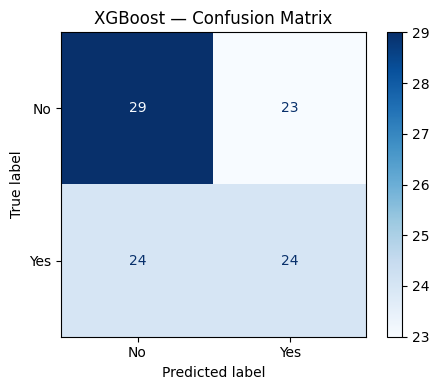

In [63]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=xgb_cm, display_labels=["No", "Yes"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("XGBoost — Confusion Matrix")
plt.tight_layout()
plt.show()

## Hyper parameter tuning

In [64]:
from sklearn.model_selection import RandomizedSearchCV

In [80]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "Classifier__n_estimators": [200, 300, 500],
    "Classifier__max_depth": [3, 4, 5, 6],
    "Classifier__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "Classifier__subsample": [0.7, 0.8, 1.0],
    "Classifier__colsample_bytree": [0.7, 0.8, 1.0]
}

In [81]:
print(XGB_Pipeline.named_steps.keys())

dict_keys(['Preprocessor', 'Classifier'])


In [82]:
search = RandomizedSearchCV(
    estimator=XGB_Pipeline,
    param_distributions=param_grid,
    n_iter=20,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

search.fit(X_train, y_train)

print("Best AUC-PR (CV):", search.best_score_)
print("Best Params:", search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best AUC-PR (CV): 0.6049318465047688
Best Params: {'Classifier__subsample': 0.8, 'Classifier__n_estimators': 300, 'Classifier__max_depth': 3, 'Classifier__learning_rate': 0.01, 'Classifier__colsample_bytree': 0.8}


# Create the best model

In [83]:
best_xgb_pipeline = search.best_estimator_

## predict

In [85]:
xgb_tuned_pred = best_xgb_pipeline.predict(X_test)
xgb_tuned_proba = best_xgb_pipeline.predict_proba(X_test)[:, 1]

In [87]:
xgb_tuned_accuracy = accuracy_score(y_test, xgb_tuned_pred)
xgb_tuned_precision = precision_score(y_test, xgb_tuned_pred)
xgb_tuned_recall = recall_score(y_test, xgb_tuned_pred)
xgb_tuned_f1 = f1_score(y_test, xgb_tuned_pred)
xgb_tuned_auc_pr = average_precision_score(y_test, xgb_tuned_proba)

print("=== Tuned XGBoost Validation Results ===")
print(f"Accuracy:  {xgb_tuned_accuracy:.4f}")
print(f"Precision: {xgb_tuned_precision:.4f}")
print(f"Recall:    {xgb_tuned_recall:.4f}")
print(f"F1 Score:  {xgb_tuned_f1:.4f}")
print(f"AUC-PR:    {xgb_tuned_auc_pr:.4f}")
print()
print(classification_report(y_test, xgb_tuned_pred))

xgb_tuned_cm = confusion_matrix(y_test, xgb_tuned_pred)
print("Confusion Matrix:")
print(xgb_tuned_cm)

=== Tuned XGBoost Validation Results ===
Accuracy:  0.5800
Precision: 0.5682
Recall:    0.5208
F1 Score:  0.5435
AUC-PR:    0.5971

              precision    recall  f1-score   support

           0       0.59      0.63      0.61        52
           1       0.57      0.52      0.54        48

    accuracy                           0.58       100
   macro avg       0.58      0.58      0.58       100
weighted avg       0.58      0.58      0.58       100

Confusion Matrix:
[[33 19]
 [23 25]]


# Save the tuned XGBoost model

In [88]:
import pickle

with open("Finenova_final_model.pkl", "wb") as f:
    pickle.dump(best_xgb_pipeline, f)

print("Model saved successfully")

Model saved successfully


# Load and Prep Test File

In [ ]:
test_df = pd.read_csv("test.csv")
print(test_df.shape)
test_df.head()

In [ ]:
test_ids = test_df["startup_id"]
X_test = test_df.drop(columns=["startup_id"])

In [ ]:
print(set(X_test.columns) == set(X_train.columns))

## Predict on Test Set

In [ ]:
test_pred = best_xgb_pipeline.predict(X_test)
test_proba = best_xgb_pipeline.predict_proba(X_test)[:, 1]

# Build submission.csv

In [ ]:
submission = pd.DataFrame({
    "startup_id": test_ids,
    "acquired_or_ipo": test_pred
})

# Map back to Yes/No if organizers expect string labels
submission["acquired_or_ipo"] = submission["acquired_or_ipo"].map({1: "Yes", 0: "No"})

submission.to_csv("submission.csv", index=False)
print(submission.head())
print(f"\nSubmission shape: {submission.shape}")

# Download the file (Google Colab)

In [ ]:
from google.colab import files

files.download("submission.csv")

# Download pkl file

In [ ]:
from google.colab import files
files.download("Finenova_final_model.pkl")